# Mechanism demo: watching backprop

This notebook visualizes *how* the autograd engine computes gradients. Each `Value` records its inputs and the operation that made it, so the whole computation graph can be drawn and the backward pass animated node by node.

- **green** node = positive gradient, **red** = negative, deeper color = larger magnitude (scaled to the biggest gradient in the graph)
- **white** = gradient is exactly zero (the node has no effect on the output)

In [1]:
import os, sys

# make the micrograd package importable when running from examples/
ROOT = os.path.abspath("..")
sys.path.insert(0, ROOT)
ASSETS = os.path.join(ROOT, "assets")
os.makedirs(ASSETS, exist_ok=True)

from micrograd.engine import Value
from micrograd.viz import draw_dot, animate_backward

## A single neuron

Two inputs `x1, x2`, their weights `w1, w2`, a bias `b`, summed and squashed with `tanh`. Note `x2 = 0`, so its weight `w2` will end up with a gradient of exactly zero.

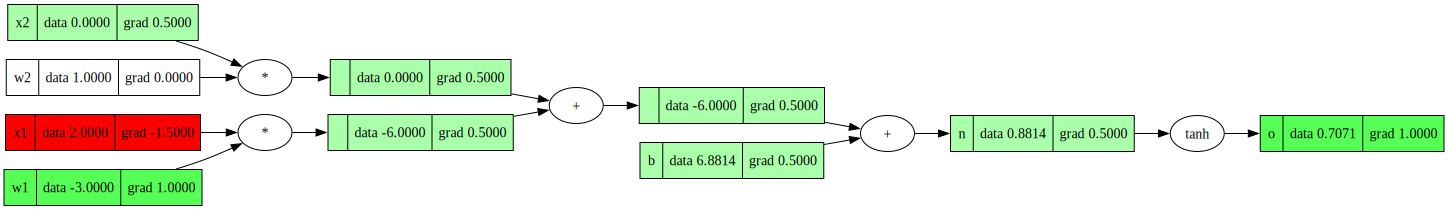

In [2]:
x1 = Value(2.0, label="x1"); w1 = Value(-3.0, label="w1")
x2 = Value(0.0, label="x2"); w2 = Value(1.0, label="w2")
b  = Value(6.88137, label="b")

n = (x1 * w1 + x2 * w2 + b); n.label = "n"
o = n.tanh(); o.label = "o"

o.backward()
draw_dot(o)  # final colored graph displays inline

## Animate the backward pass

Replays `backward()` one node at a time and saves a GIF into `assets/`. Watch the color spread from the output `o` back to the inputs.

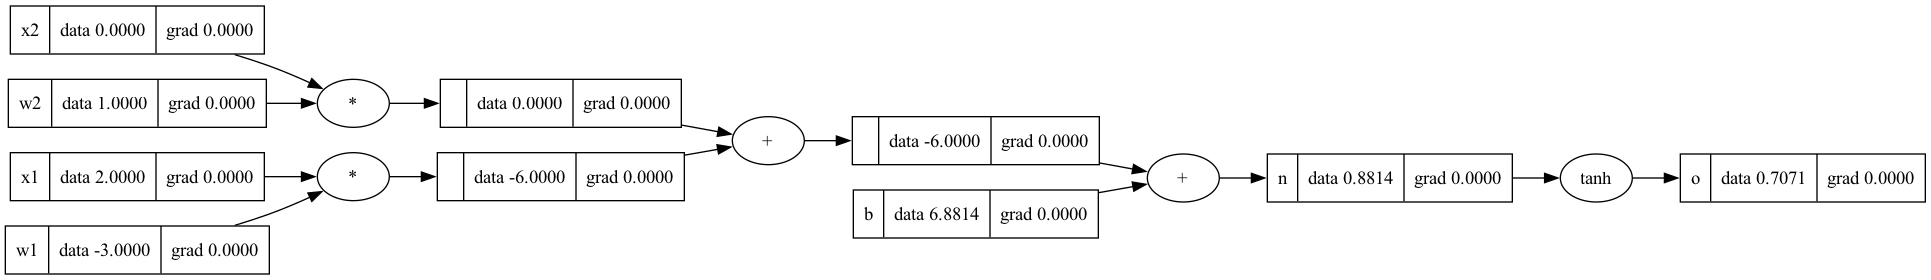

In [3]:
from IPython.display import Image

gif_path = os.path.join(ASSETS, "backward.gif")
animate_backward(o, gif_path)
Image(filename=gif_path)